
# Triadic Cell Notebook v4
## Vector state, selective readout, external memory, baseline comparison

This is the next step after v3.

What changes in v4:

1. **Vector latent state**
   - the machine no longer has one scalar internal value
   - it has a small internal register vector

2. **Selective readout**
   - the bus does not expose the whole state
   - it exposes a projected view of **bound transformed difference**

3. **External persistent memory**
   - memory is not just another internal scalar
   - it is its own register outside the cell

4. **Plain TR baseline**
   - this gives a comparison against a transform/readout machine with weak or absent binding

The target pattern is still:

- **BTR** = real machine
- **BT** = active internal machine, dark outside
- **BR** = stable shell, mostly frozen
- **TR** = flicker / collapse
- **Plain TR baseline** = obvious non-triadic control



## Hardware translation

This notebook uses the machine picture directly:

- **Binding (B)** = register protection / retained state
- **Transformation (T)** = lawful update of the register
- **Readout (R)** = bus projection of meaningful delta
- **External Memory** = persistent store of readable difference

The important shift is this:

**Memory is now outside the cell.**

That is closer to a real machine architecture.


In [2]:

from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

print("Environment ready.")


Environment ready.


In [3]:

@dataclass
class VectorTriadicState:
    coherence: float = 0.72
    latent: np.ndarray = None
    readout: np.ndarray = None

    def __post_init__(self):
        if self.latent is None:
            self.latent = np.array([0.20, 0.35, 0.50, 0.15], dtype=float)
        if self.readout is None:
            self.readout = np.zeros(2, dtype=float)



## External memory register

This is the first explicit move toward a real substrate.

Memory is no longer just an internal field.
It is a separate object that accumulates retained readable difference.


In [4]:

class ExternalMemoryRegister:
    def __init__(self, size: int = 2, leak: float = 0.02):
        self.value = np.zeros(size, dtype=float)
        self.leak = float(leak)

    def update(self, gain: np.ndarray) -> np.ndarray:
        self.value = np.clip((1.0 - self.leak) * self.value + gain, 0.0, 1.0)
        return self.value.copy()



## TriadicCellV4

Design principles:

1. **Binding** restores coherence and protects the latent register.
2. **Transformation** moves the latent register toward an input-shaped target.
3. **Readout** exposes a projected view of delta, not raw state.
4. **Memory** only grows from sustained readable delta under BTR support.
5. **Unsupported transformation** burns coherence and latent state.


In [5]:

class TriadicCellV4:
    def __init__(self, B: float, T: float, R: float):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

        # Readout projection: bus sees selected combinations of latent delta.
        self.W = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def step(
        self,
        s: VectorTriadicState,
        drive_vec: np.ndarray,
        ext_memory: ExternalMemoryRegister,
    ) -> Tuple[VectorTriadicState, np.ndarray, np.ndarray, np.ndarray]:

        # --- Binding / coherence ---
        delta_load = np.linalg.norm(s.readout)
        coherence_restore = 0.05 * self.B * (0.84 - s.coherence)
        coherence_burn = 0.07 * self.T * (1.0 - self.B) + 0.01 * delta_load
        coherence = float(np.clip(s.coherence + coherence_restore - coherence_burn, 0.0, 1.0))

        # --- Latent register / transformation ---
        target = np.array([
            0.15 + 0.70 * drive_vec[0],
            0.20 + 0.60 * drive_vec[1],
            0.25 + 0.55 * drive_vec[2],
            0.10 + 0.75 * drive_vec[3],
        ], dtype=float)

        follow = 0.20 * self.B * self.T * coherence * (target - s.latent)
        static_drag = 0.04 * (1.0 - self.T) * (s.latent - np.array([0.20, 0.35, 0.50, 0.15]))
        unsupported_loss = 0.14 * self.T * (1.0 - self.B) * s.latent

        latent = self._clip(s.latent + follow - static_drag - unsupported_loss)
        delta_vec = np.abs(latent - s.latent)

        # --- Readout / bus ---
        support = self.B * self.T * self.R * coherence
        projected = self.W @ delta_vec
        projected = np.maximum(projected, 0.0)

        shell_decay = (0.18 * (1.0 - self.T) + 0.12 * (1.0 - self.R)) * s.readout
        readout = self._clip(0.82 * s.readout + 2.40 * support * projected - shell_decay)

        # --- External memory ---
        gain = 0.45 * support * readout
        memory = ext_memory.update(gain)

        next_state = VectorTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state, readout.copy(), delta_vec.copy(), memory.copy()



## Plain TR baseline

This is the control system.

It transforms and emits, but it does **not** have a real binding-centered memory architecture.
That gives you a side-by-side comparison against a non-triadic machine.


In [6]:

class PlainTRBaseline:
    def __init__(self):
        self.W = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def step(
        self,
        s: VectorTriadicState,
        drive_vec: np.ndarray,
    ) -> Tuple[VectorTriadicState, np.ndarray, np.ndarray]:

        coherence = float(np.clip(s.coherence - 0.08 - 0.02 * np.linalg.norm(s.readout), 0.0, 1.0))

        target = np.array([
            0.15 + 0.70 * drive_vec[0],
            0.20 + 0.60 * drive_vec[1],
            0.25 + 0.55 * drive_vec[2],
            0.10 + 0.75 * drive_vec[3],
        ], dtype=float)

        latent = self._clip(s.latent + 0.10 * coherence * (target - s.latent) - 0.18 * s.latent)
        delta_vec = np.abs(latent - s.latent)

        projected = self.W @ delta_vec
        projected = np.maximum(projected, 0.0)
        readout = self._clip(0.65 * s.readout + 1.40 * projected - 0.35 * s.readout)

        next_state = VectorTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state, readout.copy(), delta_vec.copy()



## Drive signal

Now the input itself is a vector.
That gives the machine several channels to sort and project.


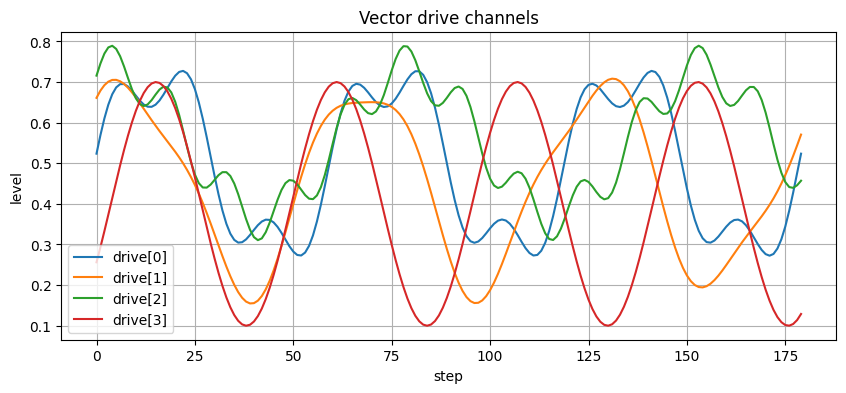

In [7]:

def make_drive(steps: int = 180) -> np.ndarray:
    t = np.linspace(0, 6 * np.pi, steps)

    v0 = np.clip(0.50 + 0.22 * np.sin(t) + 0.08 * np.sin(3.0 * t + 0.3), 0.0, 1.0)
    v1 = np.clip(0.45 + 0.25 * np.sin(t + 0.7) + 0.05 * np.cos(2.2 * t), 0.0, 1.0)
    v2 = np.clip(0.55 + 0.18 * np.cos(0.8 * t - 0.4) + 0.06 * np.sin(4.0 * t), 0.0, 1.0)
    v3 = np.clip(0.40 + 0.30 * np.sin(1.3 * t - 0.5), 0.0, 1.0)

    return np.vstack([v0, v1, v2, v3]).T

drive = make_drive()

plt.figure(figsize=(10, 4))
for i in range(drive.shape[1]):
    plt.plot(drive[:, i], label=f"drive[{i}]")
plt.title("Vector drive channels")
plt.xlabel("step")
plt.ylabel("level")
plt.legend(loc="best")
plt.show()



## Run the structural cases


In [8]:

def run_case(name: str, B: float, T: float, R: float, steps: int = 180) -> pd.DataFrame:
    cell = TriadicCellV4(B, T, R)
    state = VectorTriadicState()
    ext = ExternalMemoryRegister(size=2, leak=0.02 + 0.10 * (1.0 - B))

    rows: List[Dict[str, float]] = []

    for i, d in enumerate(make_drive(steps)):
        state, readout, delta_vec, memory = cell.step(state, d, ext)
        rows.append({
            "step": i,
            "case": name,
            "coherence": state.coherence,
            "mean_latent": float(state.latent.mean()),
            "mean_delta": float(delta_vec.mean()),
            "mean_readout": float(readout.mean()),
            "mean_memory": float(memory.mean()),
            "peak_readout": float(readout.max()),
            "peak_memory": float(memory.max()),
        })

    return pd.DataFrame(rows)


def run_baseline(name: str = "Plain TR baseline", steps: int = 180) -> pd.DataFrame:
    cell = PlainTRBaseline()
    state = VectorTriadicState()

    rows: List[Dict[str, float]] = []

    for i, d in enumerate(make_drive(steps)):
        state, readout, delta_vec = cell.step(state, d)
        rows.append({
            "step": i,
            "case": name,
            "coherence": state.coherence,
            "mean_latent": float(state.latent.mean()),
            "mean_delta": float(delta_vec.mean()),
            "mean_readout": float(readout.mean()),
            "mean_memory": 0.0,
            "peak_readout": float(readout.max()),
            "peak_memory": 0.0,
        })

    return pd.DataFrame(rows)

results = {
    "BTR": run_case("BTR", 1.0, 1.0, 1.0),
    "BT only": run_case("BT only", 1.0, 1.0, 0.0),
    "BR only": run_case("BR only", 1.0, 0.0, 1.0),
    "TR only": run_case("TR only", 0.0, 1.0, 1.0),
    "Plain TR baseline": run_baseline(),
}

pd.concat(results.values(), ignore_index=True).head()


,step,case,coherence,mean_latent,mean_delta,mean_readout,mean_memory,peak_readout,peak_memory
0,0,BTR,0.726000,0.330819,0.030819,0.069365,0.022662,0.081778,0.026717
1,1,BTR,0.730703,0.360514,0.029696,0.122650,0.062537,0.144469,0.073686
2,2,BTR,0.734407,0.388915,0.028401,0.162487,0.114986,0.190765,0.135257
3,3,BTR,0.737354,0.415741,0.026826,0.191022,0.176069,0.222709,0.206449
4,4,BTR,0.739748,0.440667,0.024926,0.210020,0.242460,0.241939,0.282858


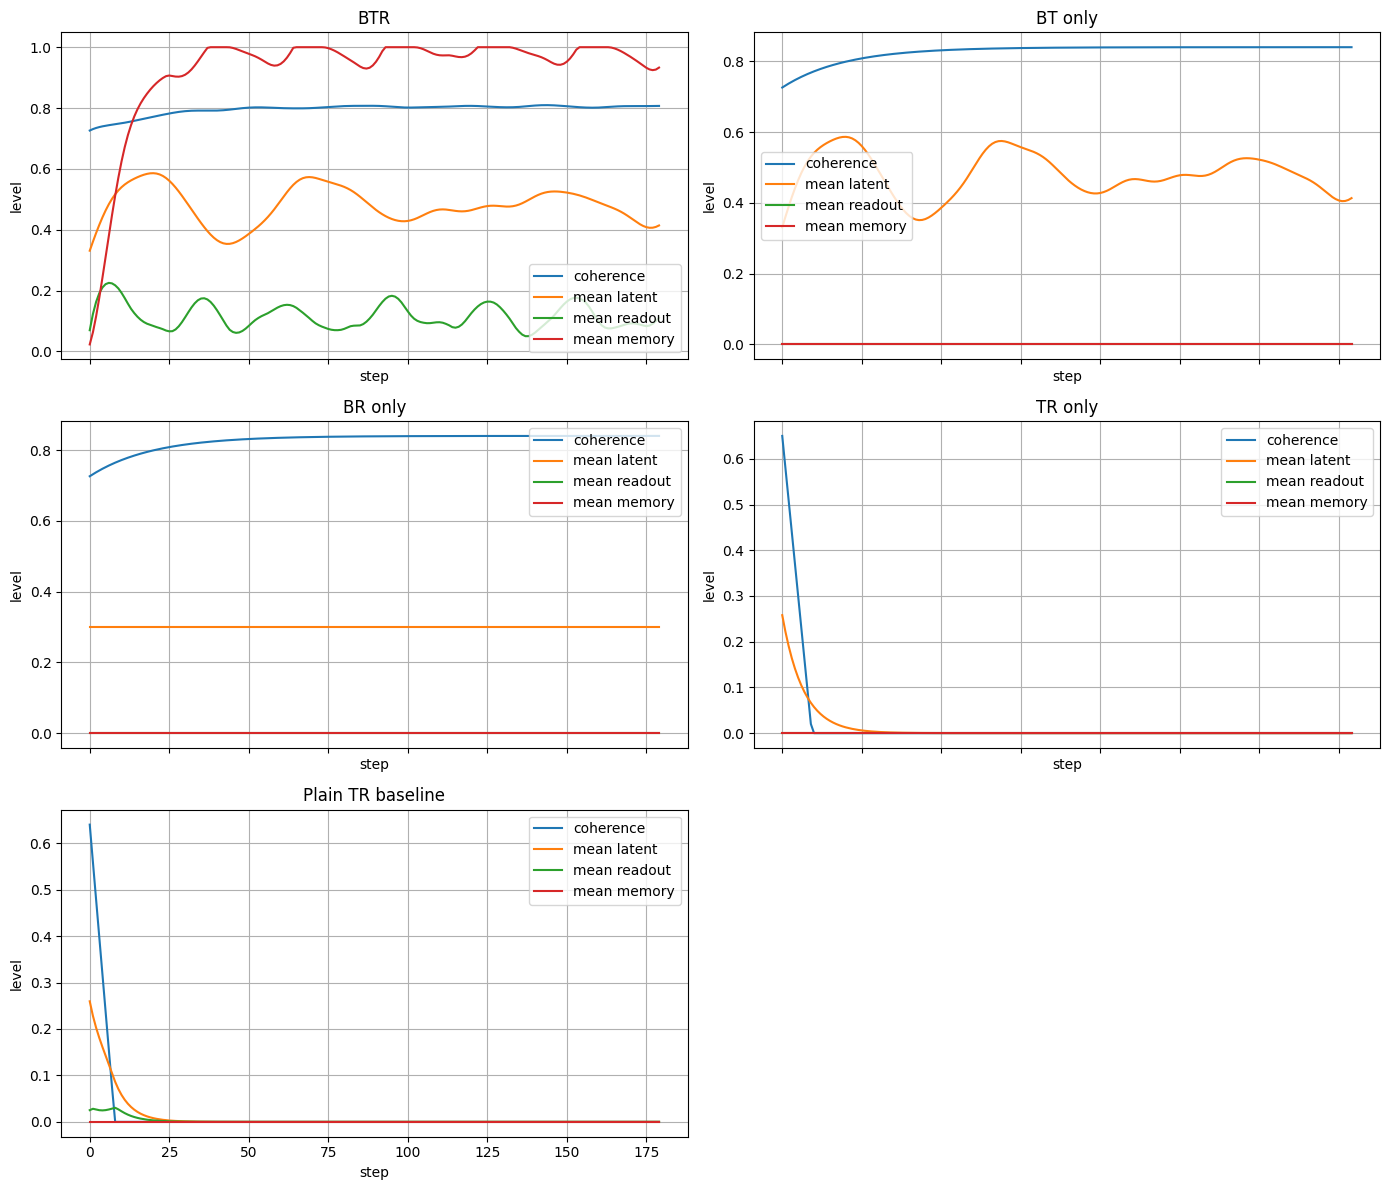

In [9]:

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes = axes.ravel()

for ax, (name, df) in zip(axes, results.items()):
    ax.plot(df["step"], df["coherence"], label="coherence")
    ax.plot(df["step"], df["mean_latent"], label="mean latent")
    ax.plot(df["step"], df["mean_readout"], label="mean readout")
    ax.plot(df["step"], df["mean_memory"], label="mean memory")
    ax.set_title(name)
    ax.set_xlabel("step")
    ax.set_ylabel("level")
    ax.legend(loc="best")

# Hide any unused subplot
if len(results) < len(axes):
    for ax in axes[len(results):]:
        ax.axis("off")

plt.tight_layout()
plt.show()



## Summary table

This is the machine-level compression.


In [10]:

summary = pd.DataFrame([
    {
        "case": name,
        "final_coherence": df["coherence"].iloc[-1],
        "final_latent": df["mean_latent"].iloc[-1],
        "final_readout": df["mean_readout"].iloc[-1],
        "final_memory": df["mean_memory"].iloc[-1],
        "mean_coherence": df["coherence"].mean(),
        "mean_delta": df["mean_delta"].mean(),
        "mean_readout": df["mean_readout"].mean(),
        "mean_memory": df["mean_memory"].mean(),
        "peak_readout": df["peak_readout"].max(),
        "peak_memory": df["peak_memory"].max(),
    }
    for name, df in results.items()
]).sort_values(["mean_memory", "mean_readout"], ascending=False)

summary


,case,final_coherence,final_latent,final_readout,final_memory,mean_coherence,mean_delta,mean_readout,mean_memory,peak_readout,peak_memory
0,BTR,0.806919,4.139168e-01,1.102986e-01,0.932976,0.795583,0.010289,0.115414,0.922431,0.24990,1.0
4,Plain TR baseline,0.000000,1.576283e-16,6.272259e-17,0.000000,0.015884,0.001667,0.002194,0.000000,0.03466,0.0
1,BT only,0.839988,4.134874e-01,0.000000e+00,0.000000,0.827335,0.010426,0.000000,0.000000,0.00000,0.0
2,BR only,0.839988,3.000000e-01,0.000000e+00,0.000000,0.827335,0.000000,0.000000,0.000000,0.00000,0.0
3,TR only,0.000000,4.862308e-13,0.000000e+00,0.000000,0.018611,0.001667,0.000000,0.000000,0.00000,0.0



## Scorecard

Statefulness is measured from **delta**, not from raw state level.
That avoids calling a frozen high register "alive."


In [11]:

def classify(df: pd.DataFrame) -> Dict[str, str]:
    mean_c = df["coherence"].mean()
    mean_d = df["mean_delta"].mean()
    mean_r = df["mean_readout"].mean()
    mean_m = df["mean_memory"].mean()

    return {
        "coherence": "high" if mean_c > 0.58 else "low",
        "statefulness": "high" if mean_d > 0.008 else "low",
        "readability": "high" if mean_r > 0.05 else "low",
        "memory": "high" if mean_m > 0.10 else "low",
    }

scorecard = pd.DataFrame({name: classify(df) for name, df in results.items()}).T
scorecard


,coherence,statefulness,readability,memory
BTR,high,high,high,high
BT only,high,high,low,low
BR only,high,low,low,low
TR only,low,low,low,low
Plain TR baseline,low,low,low,low



## One chained BTR machine

A real substrate is not one isolated cell.
This chains several triadic cells and lets the output of one become the input of the next.


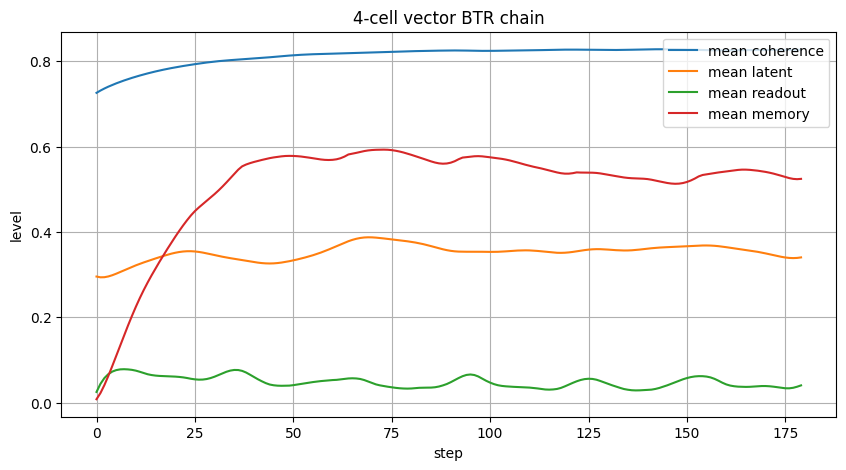

,step,mean_coherence,mean_latent,mean_delta,mean_readout,mean_memory
175,175,0.826685,0.340297,0.003378,0.033903,0.528836
176,176,0.826767,0.339252,0.003380,0.033820,0.526275
177,177,0.826866,0.338866,0.003464,0.035027,0.524435
178,178,0.826968,0.339264,0.003503,0.037524,0.523760
179,179,0.827057,0.340484,0.003407,0.040684,0.524467


In [12]:

def run_chain(depth: int = 4, steps: int = 180, B: float = 1.0, T: float = 1.0, R: float = 1.0) -> pd.DataFrame:
    cells = [TriadicCellV4(B, T, R) for _ in range(depth)]
    states = [VectorTriadicState() for _ in range(depth)]
    memories = [ExternalMemoryRegister(size=2, leak=0.02) for _ in range(depth)]

    rows = []

    for i, d in enumerate(make_drive(steps)):
        signal = d.copy()
        deltas = []

        for j, cell in enumerate(cells):
            states[j], readout, delta_vec, mem = cell.step(states[j], signal, memories[j])

            # propagate back into 4D input shape for the next cell
            signal = np.array([
                readout[0],
                readout[1],
                delta_vec.mean(),
                mem.mean(),
            ], dtype=float)
            deltas.append(delta_vec.mean())

        rows.append({
            "step": i,
            "mean_coherence": np.mean([s.coherence for s in states]),
            "mean_latent": np.mean([s.latent.mean() for s in states]),
            "mean_delta": np.mean(deltas),
            "mean_readout": np.mean([s.readout.mean() for s in states]),
            "mean_memory": np.mean([m.value.mean() for m in memories]),
        })

    return pd.DataFrame(rows)

chain_df = run_chain(depth=4, steps=180, B=1.0, T=1.0, R=1.0)

plt.figure(figsize=(10, 5))
plt.plot(chain_df["step"], chain_df["mean_coherence"], label="mean coherence")
plt.plot(chain_df["step"], chain_df["mean_latent"], label="mean latent")
plt.plot(chain_df["step"], chain_df["mean_readout"], label="mean readout")
plt.plot(chain_df["step"], chain_df["mean_memory"], label="mean memory")
plt.title("4-cell vector BTR chain")
plt.xlabel("step")
plt.ylabel("level")
plt.legend(loc="best")
plt.show()

chain_df.tail()



## Read the result

The intended pattern now is:

- **BTR** should be the only case that is strong on all four
- **BT only** should be active internally but dark externally
- **BR only** should be coherent but low-delta
- **TR only** should collapse
- **Plain TR baseline** should look like a non-binding transform/readout engine

If that holds, then the machine is getting closer to a real AI substrate:
state vector, bus projection, external memory, and explicit comparison against a weaker architecture.
